In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/hippocampal-dataset/Task520_HarP/dataset.json
/kaggle/input/hippocampal-dataset/Task520_HarP/labelTr/HarP_077.nii
/kaggle/input/hippocampal-dataset/Task520_HarP/labelTr/HarP_025.nii
/kaggle/input/hippocampal-dataset/Task520_HarP/labelTr/HarP_050.nii
/kaggle/input/hippocampal-dataset/Task520_HarP/labelTr/HarP_027.nii
/kaggle/input/hippocampal-dataset/Task520_HarP/labelTr/HarP_002.nii
/kaggle/input/hippocampal-dataset/Task520_HarP/labelTr/HarP_084.nii
/kaggle/input/hippocampal-dataset/Task520_HarP/labelTr/HarP_078.nii
/kaggle/input/hippocampal-dataset/Task520_HarP/labelTr/HarP_068.nii
/kaggle/input/hippocampal-dataset/Task520_HarP/labelTr/HarP_034.nii
/kaggle/input/hippocampal-dataset/Task520_HarP/labelTr/HarP_122.nii
/kaggle/input/hippocampal-dataset/Task520_HarP/labelTr/HarP_024.nii
/kaggle/input/hippocampal-dataset/Task520_HarP/labelTr/HarP_032.nii
/kaggle/input/hippocampal-dataset/Task520_HarP/labelTr/HarP_011.nii
/kaggle/input/hippocampal-dataset/Task520_HarP/labelTr/H

In [2]:
import numpy as np
import nibabel as nib
import os
from glob import glob
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from scipy.spatial.distance import directed_hausdorff, cdist
from scipy.ndimage import binary_erosion, zoom, label
from scipy.ndimage import binary_opening, binary_closing
import h5py
# import streamlit as st
# from pathlib import Path

DATASET_DIR = '/kaggle/input/datasets/adityachaudhary10/hippocampal-dataset'

In [3]:
image_path = "/kaggle/input/hippocampal-dataset/Task520_HarP/imageTr/HarP_000.nii"
label_path = "/kaggle/input/hippocampal-dataset/Task520_HarP/labelTr/HarP_000.nii"

img = nib.load(image_path)
lbl = nib.load(label_path)

img_data = img.get_fdata()
lbl_data = lbl.get_fdata()

print("Image Shape:", img_data.shape)
print("Label Shape:", lbl_data.shape)
print("Image Datatype:", img_data.dtype)
print("Label Unique Values:", np.unique(lbl_data))

Image Shape: (64, 64, 96)
Label Shape: (64, 64, 96)
Image Datatype: float64
Label Unique Values: [0. 1.]


In [4]:
image_paths = glob("/kaggle/input/hippocampal-dataset/Task520_HarP/imageTr/*")
# print("Found:", len(image_paths))
# print(image_paths[:5])
all_voxels = []
for img_path in image_paths:
    data = nib.load(img_path).get_fdata()
    all_voxels.append(data.flatten())

all_voxels = np.concatenate(all_voxels)

print("Min:", np.min(all_voxels))
print("Max:", np.max(all_voxels))
print("Mean:", np.mean(all_voxels))
print("Standard Deviation:", np.std(all_voxels))

Min: 0.0
Max: 6834.0
Mean: 577.7217242589195
Standard Deviation: 734.4687348762719


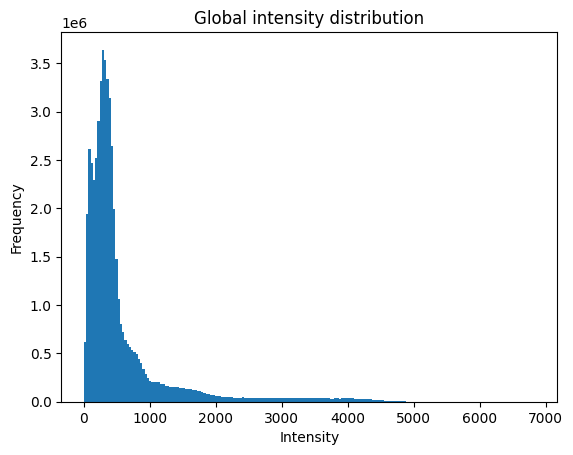

In [5]:
plt.hist(all_voxels, bins=200)
plt.title("Global intensity distribution")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.show()

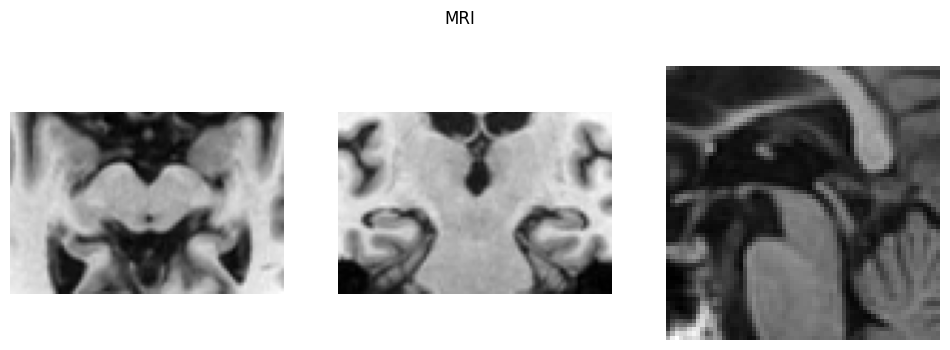

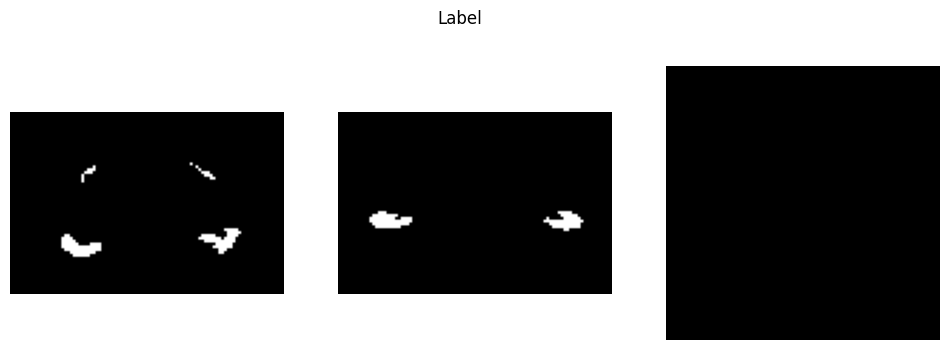

In [6]:
def show_slices(volume, title=""):
    z, y, x = volume.shape
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(volume[z//2, :, :], cmap='gray')
    axes[1].imshow(volume[:, y//2, :], cmap='gray')
    axes[2].imshow(volume[:, :, x//2], cmap='gray')
    for ax in axes:
        ax.axis('off')
    plt.suptitle(title)
    plt.show()

show_slices(img_data, "MRI")
show_slices(lbl_data, "Label")

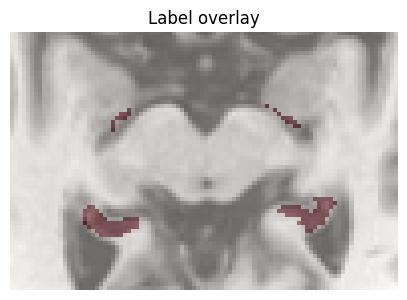

In [7]:
plt.figure(figsize=(5,5))
slice_idx = img_data.shape[0] // 2
plt.imshow(img_data[slice_idx], cmap='gray')
plt.imshow(lbl_data[slice_idx], alpha=0.4, cmap='Reds')
plt.axis('off')
plt.title("Label overlay")
plt.show()

In [8]:
hippo_voxels = np.sum(lbl_data > 0)
total_voxels = lbl_data.size

print("Hippocampus voxels:", hippo_voxels)
print("Background voxels:", total_voxels - hippo_voxels)
print("Ratio:", hippo_voxels / total_voxels)

Hippocampus voxels: 6075
Background voxels: 387141
Ratio: 0.01544952392578125


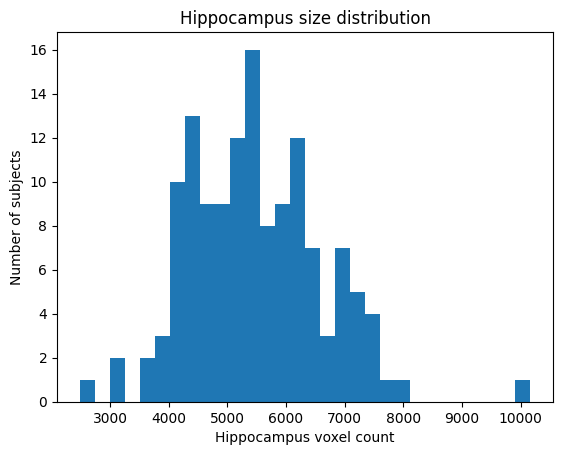

In [9]:
label_paths = glob("/kaggle/input/hippocampal-dataset/Task520_HarP/labelTr/*")
volumes = []

for lbl_path in label_paths:
    lbl = nib.load(lbl_path).get_fdata()
    volumes.append(np.sum(lbl > 0))

plt.hist(volumes, bins=30)
plt.xlabel("Hippocampus voxel count")
plt.ylabel("Number of subjects")
plt.title("Hippocampus size distribution")
plt.show()

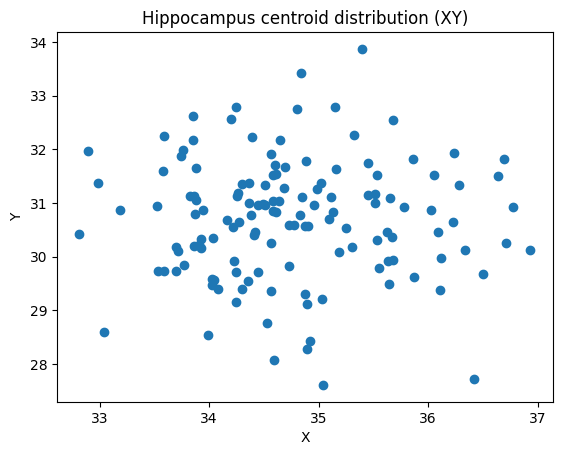

In [10]:
centroids = []

for lbl_path in label_paths:
    lbl = nib.load(lbl_path).get_fdata()
    coords = np.argwhere(lbl > 0)
    centroids.append(coords.mean(axis=0))

centroids = np.array(centroids)

plt.scatter(centroids[:,0], centroids[:,1])
plt.title("Hippocampus centroid distribution (XY)")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [11]:
np.random.shuffle(label_paths)
split = int(0.8 * len(label_paths))
train_label_paths = label_paths[:split]
val_label_paths = label_paths[split:]

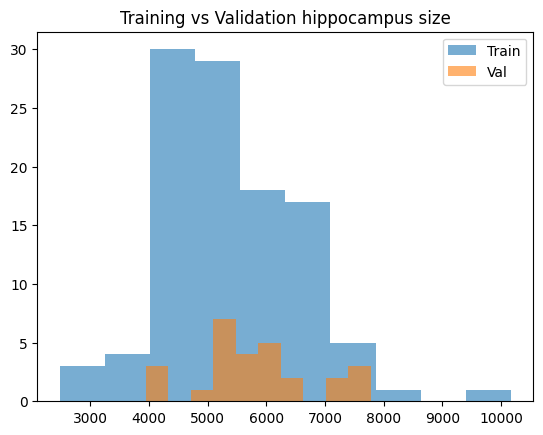

In [12]:
def compute_stats(paths):
    vols = []
    for p in paths:
        lbl = nib.load(p).get_fdata()
        vols.append(np.sum(lbl > 0))
    return np.array(vols)

train_vols = compute_stats(train_label_paths)
val_vols = compute_stats(val_label_paths)

plt.hist(train_vols, alpha=0.6, label="Train")
plt.hist(val_vols, alpha=0.6, label="Val")
plt.legend()
plt.title("Training vs Validation hippocampus size")
plt.show()

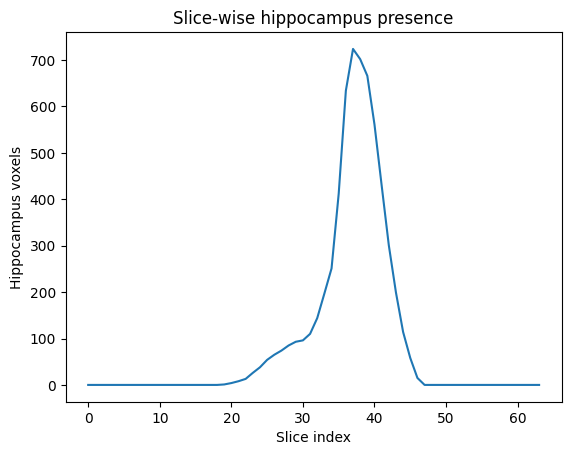

In [13]:
slice_presence = np.sum(lbl_data > 0, axis=(1,2))

plt.plot(slice_presence)
plt.xlabel("Slice index")
plt.ylabel("Hippocampus voxels")
plt.title("Slice-wise hippocampus presence")
plt.show()

In [14]:
img = nib.load(image_paths[0])
print(img.header.get_zooms())

(np.float32(1.0), np.float32(1.0), np.float32(1.0))


In [15]:
print(img.header.get_qform())
print(img.header.get_sform())

[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


In [16]:
np.unique(nib.load(label_paths[0]).get_fdata())

array([0., 1.])

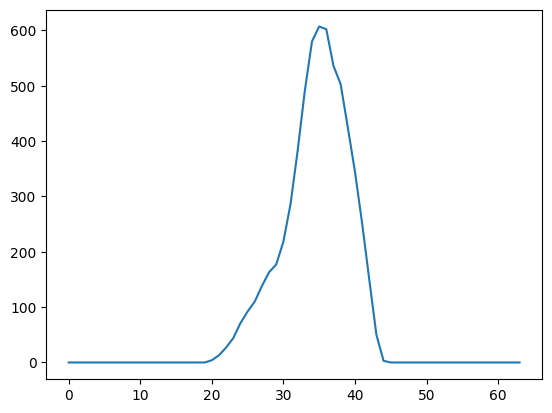

In [17]:
lbl = nib.load(label_paths[0]).get_fdata()
presence = np.sum(lbl > 0, axis=(1,2))
plt.plot(presence)

In [18]:
vol = np.array(volumes)
outliers = np.where(vol > vol.mean() + 3*vol.std())[0]
outliers

array([97])

In [19]:
boxes = []
for p in label_paths:
    lbl = nib.load(p).get_fdata()
    c = np.argwhere(lbl > 0)
    boxes.append(c.max(axis=0) - c.min(axis=0))

boxes = np.array(boxes)
boxes.mean(axis=0)

array([28.99259259, 38.56296296, 69.00740741])

In [20]:
image_paths

['/kaggle/input/hippocampal-dataset/Task520_HarP/imageTr/HarP_077.nii',
 '/kaggle/input/hippocampal-dataset/Task520_HarP/imageTr/HarP_025.nii',
 '/kaggle/input/hippocampal-dataset/Task520_HarP/imageTr/HarP_050.nii',
 '/kaggle/input/hippocampal-dataset/Task520_HarP/imageTr/HarP_027.nii',
 '/kaggle/input/hippocampal-dataset/Task520_HarP/imageTr/HarP_002.nii',
 '/kaggle/input/hippocampal-dataset/Task520_HarP/imageTr/HarP_084.nii',
 '/kaggle/input/hippocampal-dataset/Task520_HarP/imageTr/HarP_078.nii',
 '/kaggle/input/hippocampal-dataset/Task520_HarP/imageTr/HarP_068.nii',
 '/kaggle/input/hippocampal-dataset/Task520_HarP/imageTr/HarP_034.nii',
 '/kaggle/input/hippocampal-dataset/Task520_HarP/imageTr/HarP_122.nii',
 '/kaggle/input/hippocampal-dataset/Task520_HarP/imageTr/HarP_024.nii',
 '/kaggle/input/hippocampal-dataset/Task520_HarP/imageTr/HarP_032.nii',
 '/kaggle/input/hippocampal-dataset/Task520_HarP/imageTr/HarP_011.nii',
 '/kaggle/input/hippocampal-dataset/Task520_HarP/imageTr/HarP_04

In [21]:
label_paths

['/kaggle/input/hippocampal-dataset/Task520_HarP/labelTr/HarP_001.nii',
 '/kaggle/input/hippocampal-dataset/Task520_HarP/labelTr/HarP_090.nii',
 '/kaggle/input/hippocampal-dataset/Task520_HarP/labelTr/HarP_027.nii',
 '/kaggle/input/hippocampal-dataset/Task520_HarP/labelTr/HarP_094.nii',
 '/kaggle/input/hippocampal-dataset/Task520_HarP/labelTr/HarP_060.nii',
 '/kaggle/input/hippocampal-dataset/Task520_HarP/labelTr/HarP_129.nii',
 '/kaggle/input/hippocampal-dataset/Task520_HarP/labelTr/HarP_039.nii',
 '/kaggle/input/hippocampal-dataset/Task520_HarP/labelTr/HarP_025.nii',
 '/kaggle/input/hippocampal-dataset/Task520_HarP/labelTr/HarP_082.nii',
 '/kaggle/input/hippocampal-dataset/Task520_HarP/labelTr/HarP_047.nii',
 '/kaggle/input/hippocampal-dataset/Task520_HarP/labelTr/HarP_081.nii',
 '/kaggle/input/hippocampal-dataset/Task520_HarP/labelTr/HarP_102.nii',
 '/kaggle/input/hippocampal-dataset/Task520_HarP/labelTr/HarP_023.nii',
 '/kaggle/input/hippocampal-dataset/Task520_HarP/labelTr/HarP_10

In [22]:
idx = np.arange(len(image_paths))
np.random.seed(42)
np.random.shuffle(idx)

split = int(0.8 * len(idx))

train_idx = idx[:split]
val_idx   = idx[split:]

train_images = [image_paths[i] for i in train_idx]
train_labels = [label_paths[i] for i in train_idx]

val_images = [image_paths[i] for i in val_idx]
val_labels = [label_paths[i] for i in val_idx]


In [23]:
def normalize(img):
    return (img - img.mean()) / (img.std() + 1e-8)

In [24]:
class HarP2DDataset(Dataset):
    def __init__(self, image_paths, label_paths):
        self.samples = []

        for img_p, lbl_p in zip(image_paths, label_paths):
            img = normalize(nib.load(img_p).get_fdata())
            lbl = nib.load(lbl_p).get_fdata()

            for z in range(img.shape[0]):
                if np.sum(lbl[z] > 0) > 0:   # keep useful slices only
                    self.samples.append((img[z], lbl[z]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img, lbl = self.samples[idx]
        return (
            torch.tensor(img).unsqueeze(0).float(),
            torch.tensor(lbl > 0).unsqueeze(0).float()
        )


In [25]:
train_ds = HarP2DDataset(train_images, train_labels)
val_ds   = HarP2DDataset(val_images, val_labels)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=8)


In [26]:
class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=[32, 64, 128, 256]):
        super().__init__()

        self.encoders = nn.ModuleList()
        self.decoders = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Encoder blocks
        for feature in features:
            self.encoders.append(self.double_conv(in_channels, feature))
            in_channels = feature

        # Bottleneck
        self.bottleneck = self.double_conv(features[-1], features[-1]*2)

        # Decoder blocks
        for feature in reversed(features):
            self.decoders.append(nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2))
            self.decoders.append(self.double_conv(feature*2, feature))

        # Final output layer
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def double_conv(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        skip_connections = []

        # Encoder path
        for enc in self.encoders:
            x = enc(x)
            skip_connections.append(x)
            x = self.pool(x)

        # Bottleneck
        x = self.bottleneck(x)

        # Decoder path
        skip_connections = skip_connections[::-1]
        for idx in range(0, len(self.decoders), 2):
            x = self.decoders[idx](x)  # ConvTranspose (upsample)
            skip_conn = skip_connections[idx//2]
            # In case of mismatched sizes due to pooling
            if x.shape != skip_conn.shape:
                x = F.interpolate(x, size=skip_conn.shape[2:])
            x = torch.cat((skip_conn, x), dim=1)  # concatenate skip connection
            x = self.decoders[idx+1](x)  # double conv

        return self.final_conv(x)

In [27]:
def dice_loss(pred, target):
    pred = torch.sigmoid(pred)
    smooth = 1e-5
    inter = (pred * target).sum()
    return 1 - (2*inter + smooth) / (pred.sum() + target.sum() + smooth)

In [28]:
def hd95(pred_mask, gt_mask):
    """
    Compute 3D Hausdorff distance between predicted and ground truth masks.
    Both masks are binary numpy arrays of same shape.
    """
    # Get coordinates of non-zero voxels (hippocampus)
    pred_points = np.argwhere(pred_mask > 0)
    gt_points = np.argwhere(gt_mask > 0)

    if len(pred_points) == 0 or len(gt_points) == 0:
        # Empty mask → return large distance
        return np.nan

    # pairwise distance
    d_matrix = cdist(pred_points, gt_points)

    # Directed Hausdorff distances
    d_pred_to_gt = d_matrix.min(axis=1)
    d_gt_to_pred = d_matrix.min(axis=0)
    
    # 95th percentile
    hd95_val = np.percentile(np.concatenate([d_pred_to_gt, d_gt_to_pred]), 95)
    return hd95_val

In [29]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = UNet().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = int(input("Enter how many Epochs should happen: "))

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    hd_vals = []

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        pred = model(x) 
        loss = dice_loss(pred, y)
        loss.backward()
        opt.step()
        train_loss += loss.item()

        # Compute Hausdorff for **each sample in the batch**
        pred_sig = torch.sigmoid(pred).detach().cpu().numpy()  # [B, 1, H, W]
        y_np = y.cpu().numpy()                        # [B, 1, H, W]
        
        for b in range(pred_sig.shape[0]):
            pred_mask = (pred_sig[b,0] > 0.5).astype(np.uint8)
            gt_mask = (y_np[b,0] > 0.5).astype(np.uint8)
            hd_val = hd95(pred_mask, gt_mask)
            if not np.isnan(hd_val):
                hd_vals.append(hd_val)

    mean_hd = np.nan if len(hd_vals) == 0 else np.mean(hd_vals)
    print(f"Epoch {epoch+1:03d} | Train Dice Loss: {train_loss/len(train_loader):.4f} | Hausdorff Distance (HD95): {mean_hd:.4f} mm")

Enter how many Epochs should happen:  220


Epoch 001 | Train Dice Loss: 0.6254 | Hausdorff Distance (HD95): 13.3275 mm
Epoch 002 | Train Dice Loss: 0.4866 | Hausdorff Distance (HD95): 10.3960 mm
Epoch 003 | Train Dice Loss: 0.4620 | Hausdorff Distance (HD95): 9.7779 mm
Epoch 004 | Train Dice Loss: 0.4437 | Hausdorff Distance (HD95): 9.3127 mm
Epoch 005 | Train Dice Loss: 0.4202 | Hausdorff Distance (HD95): 9.2547 mm
Epoch 006 | Train Dice Loss: 0.3944 | Hausdorff Distance (HD95): 8.2286 mm
Epoch 007 | Train Dice Loss: 0.3678 | Hausdorff Distance (HD95): 8.2224 mm
Epoch 008 | Train Dice Loss: 0.3496 | Hausdorff Distance (HD95): 7.7043 mm
Epoch 009 | Train Dice Loss: 0.3204 | Hausdorff Distance (HD95): 7.3600 mm
Epoch 010 | Train Dice Loss: 0.2997 | Hausdorff Distance (HD95): 6.5955 mm
Epoch 011 | Train Dice Loss: 0.2823 | Hausdorff Distance (HD95): 6.4185 mm
Epoch 012 | Train Dice Loss: 0.2653 | Hausdorff Distance (HD95): 5.9056 mm
Epoch 013 | Train Dice Loss: 0.2564 | Hausdorff Distance (HD95): 5.7182 mm
Epoch 014 | Train Dice 

In [30]:
torch.save(model.state_dict(), "/kaggle/working/unet2d.pth")

In [31]:
# device = "cuda" if torch.cuda.is_available() else "cpu"

# model = UNet().to(device)
# model.load_state_dict(torch.load("/kaggle/working/unet2d.pth", map_location=device))
# model.eval()

save_dir = "/kaggle/working"
os.makedirs(save_dir, exist_ok=True)

# Get state_dict (weights only)
state_dict = model.state_dict()

# HDF5 file path
h5_path = os.path.join(save_dir, "unet2d_weights.h5")

# Save weights to HDF5
with h5py.File(h5_path, "w") as f:
    for k, v in state_dict.items():
        data = v.cpu().numpy()
        # Handle scalars properly
        if data.shape == ():  # scalar tensor
            f.create_dataset(k, data=data, shape=(1,))
        else:
            f.create_dataset(k, data=data)

# Define your UNet model first
model = UNet()
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# Load weights
h5_path = "/kaggle/working/unet2d_weights.h5"
with h5py.File(h5_path, "r") as f:
    state_dict = {k: torch.tensor(f[k][:]) for k in f.keys()}

model.load_state_dict(state_dict)
model.eval()

UNet(
  (encoders): ModuleList(
    (0): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(1

In [32]:
def infer_volume(model, image_path):
    img = nib.load(image_path)
    img_data = img.get_fdata()
    img_norm = normalize(img_data)

    pred_mask = np.zeros_like(img_data)

    with torch.no_grad():
        for z in range(img_data.shape[0]):
            slice_img = img_norm[z]
            inp = torch.tensor(slice_img).unsqueeze(0).unsqueeze(0).float().to(device)

            pred = model(inp)
            pred = torch.sigmoid(pred).cpu().numpy()[0,0]
            pred_mask[z] = (pred > 0.5).astype(np.uint8)

    return pred_mask, img.affine

In [33]:
def save_mask(mask, affine, out_path):
    nib.save(nib.Nifti1Image(mask, affine), out_path)

In [34]:
os.makedirs("/kaggle/working/pred_masks", exist_ok=True)

for img_path in val_images:
    mask, affine = infer_volume(model, img_path)
    fname = os.path.basename(img_path)
    save_mask(mask, affine, f"/kaggle/working/pred_masks/{fname}")

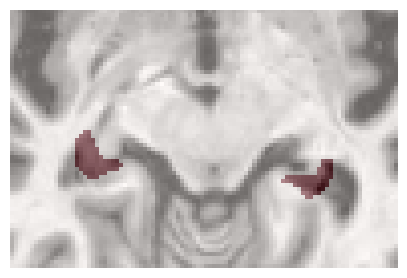

In [35]:
mask, _ = infer_volume(model, val_images[0])
slice_idx = mask.shape[0] // 2

plt.figure(figsize=(5,5))
plt.imshow(nib.load(val_images[0]).get_fdata()[slice_idx], cmap="gray")
plt.imshow(mask[slice_idx], alpha=0.4, cmap="Reds")
plt.axis("off")
plt.show()

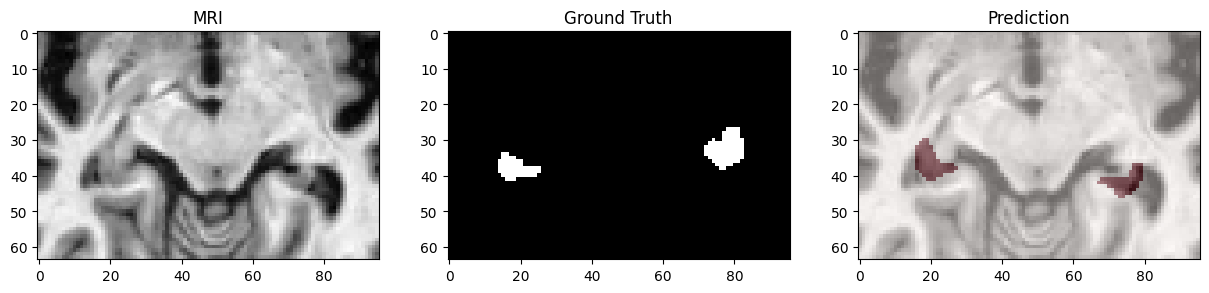

In [36]:
img = nib.load(val_images[0]).get_fdata()
lbl = nib.load(val_labels[0]).get_fdata()

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(img[slice_idx], cmap="gray")
plt.title("MRI")

plt.subplot(1,3,2)
plt.imshow(lbl[slice_idx], cmap="gray")
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(img[slice_idx], cmap="gray")
plt.imshow(mask[slice_idx], alpha=0.4, cmap="Reds")
plt.title("Prediction")

plt.show()

In [37]:
dice_list = []

for img_path, lbl_path in zip(val_images, val_labels):
    pred_mask, _ = infer_volume(model, img_path)
    gt_mask = nib.load(lbl_path).get_fdata() > 0
    
    # Convert to torch tensors
    pred_mask = torch.tensor(pred_mask, dtype=torch.float32)
    gt_mask = torch.tensor(gt_mask, dtype=torch.float32)

    dice = dice_loss(pred_mask, gt_mask).item()
    dice_list.append(dice_loss(pred_mask, gt_mask))

print("Mean Dice on Validation Set:", round(np.mean(dice_list), 4))

Mean Dice on Validation Set: 0.9677


In [38]:
hd95_list  = []

for img_path, lbl_path in zip(val_images, val_labels):
    pred_mask, _ = infer_volume(model, img_path)
    gt_mask = nib.load(lbl_path).get_fdata() > 0

    hd_val = hd95(pred_mask, gt_mask)
    hd95_list.append(hd_val)

print("Mean Hausdorff Distance (HD95) on Validation Set:",round(np.nanmean(hd95_list), 4), "mm")

Mean Hausdorff Distance (HD95) on Validation Set: 4.7625 mm


In [39]:
for i, (d, hd) in enumerate(zip(dice_list, hd95_list)):
    print(f"Subject {i}: Dice = {d:.4f} | Hausdorff Distance (HD95) = {hd:.4f} mm")

Subject 0: Dice = 0.9738 | Hausdorff Distance (HD95) = 4.5826 mm
Subject 1: Dice = 0.9626 | Hausdorff Distance (HD95) = 3.3166 mm
Subject 2: Dice = 0.9693 | Hausdorff Distance (HD95) = 3.7417 mm
Subject 3: Dice = 0.9771 | Hausdorff Distance (HD95) = 5.0990 mm
Subject 4: Dice = 0.9692 | Hausdorff Distance (HD95) = 4.0000 mm
Subject 5: Dice = 0.9561 | Hausdorff Distance (HD95) = 3.3166 mm
Subject 6: Dice = 0.9733 | Hausdorff Distance (HD95) = 6.1644 mm
Subject 7: Dice = 0.9795 | Hausdorff Distance (HD95) = 3.7417 mm
Subject 8: Dice = 0.9722 | Hausdorff Distance (HD95) = 6.4807 mm
Subject 9: Dice = 0.9592 | Hausdorff Distance (HD95) = 4.8990 mm
Subject 10: Dice = 0.9711 | Hausdorff Distance (HD95) = 4.5826 mm
Subject 11: Dice = 0.9737 | Hausdorff Distance (HD95) = 4.6904 mm
Subject 12: Dice = 0.9726 | Hausdorff Distance (HD95) = 3.1623 mm
Subject 13: Dice = 0.9653 | Hausdorff Distance (HD95) = 4.6904 mm
Subject 14: Dice = 0.9719 | Hausdorff Distance (HD95) = 4.3589 mm
Subject 15: Dice = 0

In [40]:
print("Pred shape:", pred_mask.shape)
print("GT shape:", gt_mask.shape)

Pred shape: (64, 64, 96)
GT shape: (64, 64, 96)


In [41]:
"""device = "cuda" if torch.cuda.is_available() else "cpu"

# Loading UNet Model
model = UNet().to(device)
model.load_state_dict(torch.load("/kaggle/working/unet2d.pth", map_location=device))
model.eval()

# Streamlit UI
st.title("Hippocampus Segmentation with UNet")

uploaded_file = st.file_uploader("Upload a NIfTI MRI file (.nii or .nii.gz)", type=["nii", "nii.gz"])

if uploaded_file is not None:
    # Load MRI
    img = nib.load(uploaded_file)
    img_data = img.get_fdata()
    
    # Run prediction
    mask, _ = infer_volume(model, uploaded_file.name)  # reuse your existing function
    
    # Display middle slice
    slice_idx = img_data.shape[0] // 2
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(img_data[slice_idx], cmap='gray')
    ax[0].set_title("MRI Slice")
    ax[0].axis('off')
    
    ax[1].imshow(img_data[slice_idx], cmap='gray')
    ax[1].imshow(mask[slice_idx], alpha=0.4, cmap='Reds')
    ax[1].set_title("Predicted Mask Overlay")
    ax[1].axis('off')
    
    st.pyplot(fig)
    
    # Optionally, save mask
    save_path = Path("predicted_mask.nii")
    save_mask(mask, img.affine, save_path)
    st.success(f"Predicted mask saved as {save_path.name}")"""

'device = "cuda" if torch.cuda.is_available() else "cpu"\n\n# Loading UNet Model\nmodel = UNet().to(device)\nmodel.load_state_dict(torch.load("/kaggle/working/unet2d.pth", map_location=device))\nmodel.eval()\n\n# Streamlit UI\nst.title("Hippocampus Segmentation with UNet")\n\nuploaded_file = st.file_uploader("Upload a NIfTI MRI file (.nii or .nii.gz)", type=["nii", "nii.gz"])\n\nif uploaded_file is not None:\n    # Load MRI\n    img = nib.load(uploaded_file)\n    img_data = img.get_fdata()\n    \n    # Run prediction\n    mask, _ = infer_volume(model, uploaded_file.name)  # reuse your existing function\n    \n    # Display middle slice\n    slice_idx = img_data.shape[0] // 2\n    \n    fig, ax = plt.subplots(1, 2, figsize=(10, 5))\n    ax[0].imshow(img_data[slice_idx], cmap=\'gray\')\n    ax[0].set_title("MRI Slice")\n    ax[0].axis(\'off\')\n    \n    ax[1].imshow(img_data[slice_idx], cmap=\'gray\')\n    ax[1].imshow(mask[slice_idx], alpha=0.4, cmap=\'Reds\')\n    ax[1].set_title("Pre